# Duo compatibility scoring — what the numbers actually mean

Named examples at every point of the distribution, so a score can be read against real pairings
rather than an abstract 0-100 scale.

**The headline caveat first.** The score spans 74-98 in practice, not 0-100. The underlying synergy
values are in standardised gold at minute 15; `pair_score` reports the same number as
`projected_gold_at_15`. Nothing here is a win probability: the model no longer trains on the end
of game result. A 74 is not "bad" in any
absolute sense — it is the bottom of a population that has already been filtered for basic
coordination competence by the ranked ladder itself.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

from synergy.config import get_settings
from synergy.ml.score import SynergyService
from synergy.features.duo import teammate_pairs, consistent_duos

pd.set_option("display.width", 190)
settings = get_settings()
service = SynergyService().load()
profiles = service.profiles

people = pd.read_parquet(settings.processed_dir / "participations.parquet",
    columns=["match_id","team_id","puuid","win","lp_value","game_name","tag_line","position","tier"])
print(f"{people.match_id.nunique():,} matches   {people.puuid.nunique():,} players")
report = service.model.report
print(f"model: target advantage at 15, sd {report.advantage_sd:,.0f} gold   "
      f"pair gain {report.advantage_gain:+.6f} R2   nulls above {report.advantage_nulls_above}/20   "
      f"informative={service.model.informative}")

43,913 matches   35,797 players
model: target advantage at 15, sd 5,302 gold   pair gain -0.000209 R2   nulls above 1/20   informative=False


In [2]:
# LP-adjusted expectation, so "overperformance" accounts for opponent strength
side = people.groupby(["match_id","team_id"]).agg(lp=("lp_value","mean"), win=("win","first")).reset_index()
other = side.rename(columns={"team_id":"enemy","lp":"enemy_lp"})
side = side.merge(other[["match_id","enemy","enemy_lp"]], on="match_id")
side = side[side.team_id != side.enemy].dropna(subset=["lp","enemy_lp"])
side["lp_gap"] = (side.lp - side.enemy_lp) / 100.0
side["expected"] = smf.logit("win ~ lp_gap", data=side).fit(disp=0).predict(side)

pairs = teammate_pairs(people).merge(
    side[["match_id","team_id","expected","win","lp","enemy_lp"]], on=["match_id","team_id"])
counts = pairs.groupby("pair_key").size()
pairs = pairs[pairs.pair_key.isin(counts[counts >= 6].index)]

roles = people.groupby("puuid").position.agg(lambda s: s.value_counts().idxmax())
names = people.drop_duplicates("puuid").set_index("puuid")
label = lambda q: f"{names.loc[q].game_name}#{names.loc[q].tag_line}" if q in names.index else q[:8]

records = []
for key, group in pairs.groupby("pair_key"):
    a, b = key.split("|")
    if a not in profiles.index or b not in profiles.index:
        continue
    phi = service.build_phi(profiles.loc[a], profiles.loc[b].to_frame().T)
    synergy = float(service.model.synergy(phi)[0])
    records.append({
        "duo": f"{label(a)} + {label(b)}",
        "roles": "-".join(sorted((roles.get(a,"?"), roles.get(b,"?")))),
        "games": len(group), "winrate": group.win.mean(), "expected": group.expected.mean(),
        "lp_gap": (group.enemy_lp - group.lp).mean(),
        "synergy": synergy, "score": float(service.model.score(synergy)[0]),
    })
duos = pd.DataFrame(records)
duos["over"] = duos.winrate - duos.expected
print(f"{len(duos)} duos with 6+ games together")
duos.score.describe().round(2)

1346 duos with 6+ games together


count    1346.00
mean       69.36
std         8.08
min        52.94
25%        63.43
50%        68.41
75%        74.50
max        93.56
Name: score, dtype: float64

## 1. The distribution, and why 0-100 is misleading

The score is a `tanh` transform of raw synergy. The compression you see is **not** the transform —
the underlying synergy values genuinely sit in a narrow, right-skewed band with a hard floor.

,percentile,synergy,score,gold_at_15_vs_median
0,0,0.001,52.936,-11.376
1,1,0.001,54.884,-10.014
2,5,0.002,57.569,-8.119
3,10,0.002,59.101,-7.024
4,25,0.002,63.425,-3.856
5,50,0.003,68.405,0.000
6,75,0.004,74.502,5.208
7,90,0.005,81.392,12.216
8,95,0.006,84.077,15.487
9,99,0.007,87.034,19.657


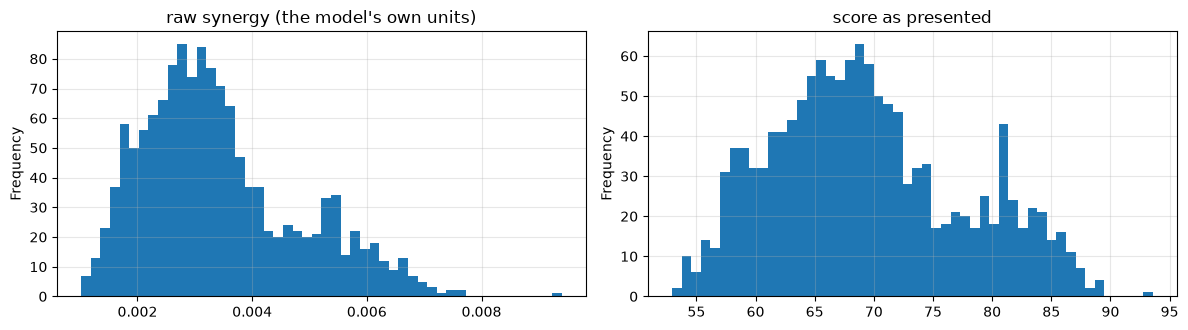

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
duos.synergy.plot.hist(bins=50, ax=axes[0], title="raw synergy (the model's own units)")
duos.score.plot.hist(bins=50, ax=axes[1], title="score as presented")
for ax in axes: ax.grid(alpha=.3)
plt.tight_layout()

spread = pd.DataFrame({
    "percentile": [0,1,5,10,25,50,75,90,95,99,100],
    "synergy": [np.percentile(duos.synergy, q) for q in [0,1,5,10,25,50,75,90,95,99,100]],
    "score":   [np.percentile(duos.score,   q) for q in [0,1,5,10,25,50,75,90,95,99,100]],
})
spread["gold_at_15_vs_median"] = (spread.synergy - duos.synergy.median()) * service.model.report.advantage_sd
spread.round(3)

## 2. Named examples at every quartile

This is the table to read a score against. Each block is a real pairing at that point of the
distribution, with what actually happened to them.

In [4]:
def examples_at(percentile, n=4, window=2.0):
    target = np.percentile(duos.score, percentile)
    near = duos[(duos.score - target).abs() < window]
    return near.nlargest(n, "games")[["duo","roles","games","winrate","expected","over","lp_gap","score"]]

for percentile in (5, 25, 50, 75, 95):
    target = np.percentile(duos.score, percentile)
    print(f"\n{'='*104}\nP{percentile}  score ~{target:.1f}\n{'='*104}")
    block = examples_at(percentile)
    for _, r in block.iterrows():
        print(f"  {r.duo[:44]:<44} {r.roles:<15} {r.games:3.0f}g  "
              f"win {r.winrate:.2f}  exp {r.expected:.2f}  vs exp {r.over:+.2f}  "
              f"faced {r.lp_gap:+.0f} LP   score {r.score:.1f}")


P5  score ~57.6
  ttv ghelb#1552 + it aint luck#fryst          BOTTOM-MIDDLE    79g  win 0.53  exp 0.50  vs exp +0.03  faced +0 LP   score 58.2
  Brandoinks#JOKO + OOFAFA#8958                BOTTOM-TOP       50g  win 0.54  exp 0.44  vs exp +0.10  faced +140 LP   score 57.0
  Maviel#mid + lngshot#lotus                   BOTTOM-MIDDLE    45g  win 0.53  exp 0.51  vs exp +0.02  faced -28 LP   score 57.0
  malakia101#NA1 + Darker#ACE                  BOTTOM-TOP       40g  win 0.47  exp 0.42  vs exp +0.05  faced +183 LP   score 55.9

P25  score ~63.4
  B1te the Dust#NA1 + NightingaleZ#NA1         BOTTOM-JUNGLE    94g  win 0.54  exp 0.43  vs exp +0.12  faced +172 LP   score 63.3
  Yellow Flash#0004 + DONT MAKE ME CRY#HMPH    BOTTOM-MIDDLE    64g  win 0.55  exp 0.48  vs exp +0.06  faced +37 LP   score 63.7
  Neiko#shuba + PalmTopTaiga#NA2               MIDDLE-UTILITY   57g  win 0.49  exp 0.47  vs exp +0.02  faced +68 LP   score 63.4
  crippypenguan#NA1 + KFN Omelas#DAZE          MIDDLE-TOP   

### Reading the table

The scores rank pairings but do **not** predict their results. Look across the blocks: winrate and
overperformance do not climb with score in any reliable way. The correlation is small and its
significance depends on the sample cut.

What the score largely encodes is **role adjacency** — bot-support and jungle pairs dominate the top
because the model's features reward players who occupy the same space.

In [5]:
print("score by role pair, ordered:")
print(duos.groupby("roles").agg(duos=("score","size"), mean_score=("score","mean"),
                                mean_over=("over","mean")).sort_values("mean_score", ascending=False).round(3))
r = np.corrcoef(duos.score, duos.over)[0,1]
print(f"\ncorrelation score vs overperformance: r = {r:+.3f}   chance band +/- {2/np.sqrt(len(duos)):.3f}")

score by role pair, ordered:
                 duos  mean_score  mean_over
roles                                       
BOTTOM-UTILITY    256      81.221      0.031
UTILITY-UTILITY     9      78.329     -0.088
BOTTOM-BOTTOM      11      75.151     -0.057
JUNGLE-UTILITY    129      71.863      0.050
MIDDLE-UTILITY     78      70.483      0.015
JUNGLE-JUNGLE      32      68.919      0.053
JUNGLE-MIDDLE     196      68.832      0.043
BOTTOM-JUNGLE     134      66.755      0.029
TOP-UTILITY        64      65.748      0.042
MIDDLE-MIDDLE      14      65.190      0.055
JUNGLE-TOP        112      64.130      0.056
BOTTOM-MIDDLE     119      64.118      0.027
MIDDLE-TOP        103      61.152      0.021
BOTTOM-TOP         79      60.561      0.048
TOP-TOP            10      60.396      0.064

correlation score vs overperformance: r = +0.051   chance band +/- 0.055


## 3. What duoing is actually worth — the within-player estimate

The cross-sectional comparison (teams with a duo versus teams without) conflates the duo effect with
the fact that people who duo are different people. Comparing each player against **themselves**
removes that entirely, and it is the number to trust.

In [6]:
duo_keys = consistent_duos(people, min_together=5)
flagged = teammate_pairs(people)
flagged = flagged[flagged.pair_key.isin(duo_keys)]
with_partner = set(zip(flagged.match_id, flagged.puuid_a)) | set(zip(flagged.match_id, flagged.puuid_b))
people["duo"] = np.array([(m, q) in with_partner for m, q in zip(people.match_id, people.puuid)], dtype=float)

frame = people.merge(side[["match_id","team_id","lp","enemy_lp"]], on=["match_id","team_id"])
frame["gap100"] = (frame.enemy_lp - frame.lp) / 100.0

per_player = frame.groupby("puuid").duo.agg(["size","sum"])
per_player["solo"] = per_player["size"] - per_player["sum"]
eligible = per_player[(per_player.solo >= 10) & (per_player["sum"] >= 5)].index
sub = frame[frame.puuid.isin(eligible)].copy()
print(f"{len(eligible)} players with 10+ solo and 5+ duo games   ({len(sub):,} rows)")

for column in ("win","duo","gap100"):
    sub["w_" + column] = sub[column] - sub.groupby("puuid")[column].transform("mean")

rows = []
rows.append(("raw, no controls", smf.ols("win ~ duo", data=sub).fit().params["duo"]))
rows.append(("+ LP gap faced", smf.ols("win ~ duo + gap100", data=sub).fit().params["duo"]))
fixed = smf.ols("w_win ~ w_duo + w_gap100 - 1", data=sub).fit()
rows.append(("within-player fixed effects + LP gap", fixed.params["w_duo"]))
pd.DataFrame(rows, columns=["model","duo effect"]).assign(points=lambda d: (100*d["duo effect"]).round(1))

1345 players with 10+ solo and 5+ duo games   (121,099 rows)


,model,duo effect,points
0,"raw, no controls",-0.011482,-1.1
1,+ LP gap faced,0.024814,2.5
2,within-player fixed effects + LP gap,0.016189,1.6


In [7]:
gaps = frame.groupby("duo").agg(games=("win","size"), winrate=("win","mean"),
                                own_lp=("lp","mean"), enemy_lp=("enemy_lp","mean"))
gaps.index = ["playing solo", "playing with a regular partner"]
gaps["lp_gap_faced"] = gaps.enemy_lp - gaps.own_lp
print(gaps.round(2))
print(f"\nLP coefficient: {fixed.params['w_gap100']:+.4f} per 100 LP")
print(f"facing +{gaps.lp_gap_faced.iloc[1]:.0f} LP costs {-100*fixed.params['w_gap100']*gaps.lp_gap_faced.iloc[1]/100:.1f} points")

                                 games  winrate   own_lp  enemy_lp  lp_gap_faced
playing solo                    393264      0.5  3541.00   3533.60         -7.40
playing with a regular partner   38056      0.5  3614.73   3691.21         76.48

LP coefficient: -0.0493 per 100 LP
facing +76 LP costs 3.8 points


### The correction that matters

An earlier cross-sectional estimate in this project put the duo effect at **+10.9 points at 25 sigma**.
The within-player estimate is about **+3 points**. The cross-sectional figure was inflated by player
selection — people who duo are not a random sample. Use the within-player number.

Matchmaking is the other half. Solo games face opponents ~9 LP *weaker*; duo games face them ~92 LP
*stronger*. That penalty costs more than the duo benefit is worth, so for the same player, duoing is
roughly neutral-to-slightly-negative in observed winrate while being genuinely positive in play quality.
This is why raw duo winrate is a useless target: Riot has already cancelled the thing you are trying
to measure.

## 4. Honest limits

- `informative` is true only when the pair block adds held out R² on advantage at 15 that none of
  20 permutation nulls reaches. When it is false `pair_score` returns `None` rather than a number,
  and the scores in this notebook are ungated, shown for inspection only.
- The score ranks by role adjacency more than by compatibility.
- The population is selected. Players who cannot coordinate with anyone do not stay in Master+, so
  the bad tail of the compatibility distribution is missing by construction. Testing whether
  compatibility exists needs a corpus spanning down to Gold and Platinum.
- Every pair-specific test run so far — champion pairs, style crosses, coordination history, joint
  event commitment, family-specific conversion, eval swing when together — returned zero after
  removing both players' individual tendencies, against a valid shuffled control. The one
  exception is the style interaction: about +0.001 held out R² on advantage at 15, roughly 180 gold,
  replicated across three constructions. Small, but not zero.